# Poređenje modela

U ovoj svesci ćemo objediniti rezultate svih šest modela lestvice (M0–M5): zbirna tabela i grafičko poređenje, provera da li su izmerene razlike statistički stvarne (Vilsonovi intervali poverenja i McNemarov test), matrice konfuzije, ROC krive i kalibracija, i na kraju provera robusnosti nad pandemijskim sezonama, koje su namerno izostavljene iz treninga. Zaključak na kraju sveske je ujedno i zaključak celog projekta.

Sveska ništa ne trenira i ne dodiruje test skup ponovo: metrike čitamo iz `reports/rezultati.csv`, a predikcije po pojedinačnom meču iz `reports/predvidjanja-test.csv`, koje je upisala sveska 05-01. Brojevi su time po konstrukciji isti kao tamo.

Skup podataka se može preuzeti sa [ove](https://www.kaggle.com/datasets/nathanlauga/nba-games) adrese.

## Priprema

In [1]:
import sys
sys.path.append("..")

import joblib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn import calibration
from sklearn import metrics as sklearn_metrics
from scipy import stats

import torch
from torch.utils.data import DataLoader

from src.config import (
    MODELS_PATH, PROCESSED_DATA_PATH, RANDOM_STATE,
    RESULTS_FILE, SEASON_SUSPENSION_DATE,
)
from src import data, evaluate, models, plotting, sequences, train

train.set_seed(RANDOM_STATE)


## Učitavanje podataka i predikcija

Iz `sekvence.npz` uzimamo oznake i indekse podele, kao i pune sekvence po svim sezonama — one nam trebaju tek u sekciji robusnosti, koja gleda pandemijske sezone. `base_rate` je udeo pobeda domaćina na treningu, pa je to i predikcija koju M0 daje na svakom meču.

In [2]:
X = pd.read_csv(PROCESSED_DATA_PATH / "atributi.csv")
splits = np.load(PROCESSED_DATA_PATH / "sekvence.npz")
y, train_idx, test = splits["labels"], splits["train"], splits["test"]
home_sequences, away_sequences, context = splits["home_sequences"], splits["away_sequences"], splits["context"]

base_rate = y[train_idx].mean()
n_features, n_context = home_sequences.shape[-1], context.shape[-1]

len(test)


1323

Predikcije po meču učitavamo iz `reports/predvidjanja-test.csv`, koju upisuje sveska 05-01. Fajl ima jednu vrstu po meču test skupa, kolonu `y_true` i po jednu kolonu za svaki od šest modela — jedan izvor za svaku dalju analizu, umesto da svaka iznova učitava modele i rizikuje da se brojevi tiho raziđu.

In [3]:
# predictions[model] = (y_proba, y_true) na testu, isti oblik za svih 6 modela
predictions_df = pd.read_csv(RESULTS_FILE.parent / "predvidjanja-test.csv")
assert len(predictions_df) == len(test)

y_test = predictions_df["y_true"].to_numpy()
predictions = {name: (predictions_df[name].to_numpy(), y_test) for name in plotting.MODEL_ORDER}

list(predictions)


['M0 domacin', 'M1 log. reg.', 'M2 XGBoost', 'M3 RNN', 'M4 LSTM', 'M5 GRU']

Za rekurentne mreže taj fajl sadrži jedan prolaz po modelu — onaj sa seedom `RANDOM_STATE`. Razlog je što je svaka mreža istrenirana pet puta, po jednom za svaki seed iz `config.SEEDS`, pa ne postoji jedna „ta" mreža: prijavljena metrika u `rezultati.csv` je prosek po seedovima, a analize kojima trebaju predikcije po pojedinačnom meču koriste jedan, unapred dogovoren prolaz. Isti izbor je napravljen i u sveskama 04-01/02/03, za krive učenja i matrice konfuzije.

Sekcija robusnosti niže ipak učitava mreže direktno, jer pandemijske sezone nisu u `predvidjanja-test.csv`. Pošto `train.save_model` čuva samo `state_dict` (težine, ne i arhitekturu), mreža se pre učitavanja mora napraviti sa istim hiperparametrima koje je izabrala dvostepena pretraga u svesci 04 — inače se oblici težina ne bi poklopili. Klasični modeli su cele `joblib` datoteke pa nemaju taj uslov.

In [4]:
# hiperparametri (rezultat dvostepene pretrage u sveskama 04-01/02/03) i klasicni modeli -
# potrebni samo za sekciju robusnosti nize, predvidjanja-test.csv ne pokriva kovid sezone
HYPERPARAMS = {
    "M3 RNN": dict(cell="rnn", hidden_size=64, dropout=0.15),
    "M4 LSTM": dict(cell="lstm", hidden_size=32, dropout=0.3),
    "M5 GRU": dict(cell="gru", hidden_size=32, dropout=0.3),
}

model_log_reg = joblib.load(MODELS_PATH / "log_reg.joblib")
model_xgb = joblib.load(MODELS_PATH / "m2_xgboost.joblib")


## Rasipanje po seedovima na testu

Pre nego što uporedimo modele međusobno, vredi izmeriti koliko se rezultat menja samo od slučajnosti u treniranju. Svaka rekurentna mreža je istrenirana pet puta, sa pet različitih seedova; sveska 05-01 upisuje pojedinačne prolaze u `reports/rasipanje-semena.csv`, dok `rezultati.csv` drži samo prosek.

Ovo merenje postavlja prag za sve što sledi: razlika između dva modela ima smisla tek ako je veća od razlike između dva pokretanja istog modela.

In [5]:
df_seed_test = pd.read_csv(evaluate.SEED_RESULTS_FILE)
df_seed_test = df_seed_test[(df_seed_test["skup"] == "test") & (df_seed_test["model"].isin(HYPERPARAMS))]

# skup je konstantno "test" posle filtriranja, pa se izbacuje iz prikaza
df_seed_test.sort_values(["model", "seed"]).drop(columns="skup").reset_index(drop=True).round(4)


,model,seed,tacnost,roc_auc,log_loss,brier
0,M3 RNN,7,0.6425,0.6797,0.6426,0.2250
1,M3 RNN,17,0.6515,0.6742,0.6491,0.2275
2,M3 RNN,27,0.6500,0.6805,0.6468,0.2265
3,M3 RNN,37,0.6538,0.6817,0.6403,0.2241
4,M3 RNN,47,0.6515,0.6794,0.6432,0.2252
5,M4 LSTM,7,0.6508,0.6817,0.6444,0.2259
6,M4 LSTM,17,0.6440,0.6831,0.6430,0.2254
7,M4 LSTM,27,0.6447,0.6781,0.6470,0.2272
8,M4 LSTM,37,0.6447,0.6813,0.6442,0.2258
9,M4 LSTM,47,0.6379,0.6796,0.6435,0.2254


In [6]:
# ddof=0 namerno - isti obrazac kao train.refine_hyperparameters, da se rasipanje racuna isto svuda u projektu
rasipanje_rows = []
for name in HYPERPARAMS:
    podskup = df_seed_test[df_seed_test["model"] == name]
    rasipanje_rows.append({
        "model": name,
        "tacnost_prosek": podskup["tacnost"].mean(),
        "tacnost_rasipanje": podskup["tacnost"].std(ddof=0),
        "roc_auc_prosek": podskup["roc_auc"].mean(),
        "roc_auc_rasipanje": podskup["roc_auc"].std(ddof=0),
    })

pd.DataFrame(rasipanje_rows).round(4)


,model,tacnost_prosek,tacnost_rasipanje,roc_auc_prosek,roc_auc_rasipanje
0,M3 RNN,0.6499,0.0039,0.6791,0.0026
1,M4 LSTM,0.6444,0.0041,0.6807,0.0017
2,M5 GRU,0.6402,0.0037,0.6793,0.0017


Rasipanje po seedovima na testu je 0.37–0.41 procentnih poena tačnosti — oko dvostruko veće nego na treningu i validaciji (0.11–0.22 p.p., `rasipanje-semena.csv`). To je i očekivano, jer je test skup (1323 meča) upola manji od validacionog (2624), pa je svaka pojedinačna procena tačnosti nesigurnija.

Ključno je poređenje sa razlikama koje želimo da tumačimo: prosečne tačnosti M1–M5 na testu staju u raspon od svega 1.0 procentnog poena (63.9–65.0%), dakle u dva do tri rasipanja. Već odavde se vidi da poredak modela na testu neće biti pouzdan — ostatak sveske to proverava formalno.

## Zbirna tabela

Sve tri podele na jednom mestu, po dogovorenom redosledu modela. Test kolonu je upisala sveska 05-01; za M3/M4/M5 je to prosek po pet seedova.

Pre nego što je 05-01 bila gotova, iste brojeve smo ovde računale nezavisno — učitavanjem sačuvanih modela i ponovnim ocenjivanjem na testu. Obe implementacije daju identične vrednosti (predikcije po meču poklapaju se do na preciznost `float32` zapisa), što je nezavisna provera da ocenjivanje nigde ne odstupa.

In [7]:
df_rezultati = pd.read_csv(RESULTS_FILE)
df_rezultati["model"] = pd.Categorical(df_rezultati["model"], categories=plotting.MODEL_ORDER, ordered=True)
df_rezultati["skup"] = pd.Categorical(df_rezultati["skup"], categories=["trening", "validacija", "test"], ordered=True)

df_rezultati.sort_values(["model", "skup"]).reset_index(drop=True).round(4)


,model,skup,tacnost,roc_auc,log_loss,brier
0,M0 domacin,trening,0.5995,0.5000,0.6732,0.2401
1,M0 domacin,validacija,0.5888,0.5000,0.6775,0.2422
2,M0 domacin,test,0.5480,0.5000,0.6940,0.2504
3,M1 log. reg.,trening,0.6725,0.7149,0.6019,0.2077
4,M1 log. reg.,validacija,0.6562,0.6953,0.6204,0.2154
5,M1 log. reg.,test,0.6417,0.6805,0.6518,0.2288
6,M2 XGBoost,trening,0.6834,0.7318,0.5908,0.2029
7,M2 XGBoost,validacija,0.6570,0.6990,0.6167,0.2138
8,M2 XGBoost,test,0.6395,0.6789,0.6487,0.2275
9,M3 RNN,trening,0.6711,0.7132,0.6035,0.2084


## Statistička značajnost

Sve što sledi radi nad predikcijama po pojedinačnom meču, pa koristi jedan prolaz po mreži — onaj sa seedom `RANDOM_STATE`. Zato se tačnosti M3/M4/M5 u tabeli ispod razlikuju od proseka po seedovima iz zbirne tabele, za 0.3 do 0.7 procentnih poena, što je reda veličine rasipanja izmerenog gore. Poredak se pritom i menja: po proseku je najbolji M3 (64.99%), a na ovom pojedinačnom prolazu M4 (65.08%) — sama ta nestabilnost je već nagoveštaj onoga što testovi ispod potvrđuju.

Tačnost je uz to samo procena nad 1323 meča, ne prava vrednost modela. Vilsonov interval poverenja pokazuje koliko je ta procena nesigurna.

In [8]:
def wilson_interval(n_correct, n_total, confidence=0.95):
    """Vilsonov interval poverenja za tacnost - pouzdaniji od normalne aproksimacije na malim uzorcima."""
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p = n_correct / n_total
    denom = 1 + z**2 / n_total
    center = (p + z**2 / (2 * n_total)) / denom
    margin = z * np.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2)) / denom
    return center - margin, center + margin


In [9]:
correct_by_model = {
    name: ((y_proba >= 0.5).astype(int) == y_true) for name, (y_proba, y_true) in predictions.items()
}

wilson_rows = []
for name in plotting.MODEL_ORDER:
    n_correct = int(correct_by_model[name].sum())
    donja, gornja = wilson_interval(n_correct, len(y_test))
    wilson_rows.append({"model": name, "tacnost": n_correct / len(y_test), "donja_granica": donja, "gornja_granica": gornja})

pd.DataFrame(wilson_rows).round(4)


,model,tacnost,donja_granica,gornja_granica
0,M0 domacin,0.5480,0.5211,0.5746
1,M1 log. reg.,0.6417,0.6155,0.6671
2,M2 XGBoost,0.6395,0.6132,0.6649
3,M3 RNN,0.6425,0.6163,0.6679
4,M4 LSTM,0.6508,0.6247,0.6760
5,M5 GRU,0.6372,0.6109,0.6627


Intervali M1–M5 se u potpunosti preklapaju, i svaki od njih je jasno iznad M0. Preklapanje intervala je ipak samo gruba naznaka, jer su intervali računati nezavisno, kao da su modeli ocenjeni na različitim uzorcima — a ocenjeni su na istim mečevima.

McNemarov test koristi upravo tu uparenost: gleda samo mečeve na kojima se dva modela razilaze i pita da li jedan od njih pobeđuje na tim mečevima značajno češće nego što bi se očekivalo od bacanja novčića. Koristimo tačnu, binomnu varijantu umesto hi-kvadrat aproksimacije, jer je pouzdanija kada je broj neslaganja mali.

In [10]:
def mcnemar_test(correct_a, correct_b):
    """Tacan (binomni) McNemarov test - pouzdaniji od hi-kvadrat aproksimacije kad je diskordantnih parova malo."""
    only_a = int(np.sum(correct_a & ~correct_b))
    only_b = int(np.sum(~correct_a & correct_b))
    n_discordant = only_a + only_b
    if n_discordant == 0:
        return 1.0
    return stats.binomtest(min(only_a, only_b), n_discordant, 0.5).pvalue


In [11]:
mcnemar_rows = []
for i, model_a in enumerate(plotting.MODEL_ORDER):
    for model_b in plotting.MODEL_ORDER[i + 1:]:
        p_vrednost = mcnemar_test(correct_by_model[model_a], correct_by_model[model_b])
        mcnemar_rows.append({"model_a": model_a, "model_b": model_b, "p_vrednost": p_vrednost})

df_mcnemar = pd.DataFrame(mcnemar_rows)
df_mcnemar.round(4)


,model_a,model_b,p_vrednost
0,M0 domacin,M1 log. reg.,0.0000
1,M0 domacin,M2 XGBoost,0.0000
2,M0 domacin,M3 RNN,0.0000
3,M0 domacin,M4 LSTM,0.0000
4,M0 domacin,M5 GRU,0.0000
5,M1 log. reg.,M2 XGBoost,0.8323
6,M1 log. reg.,M3 RNN,1.0000
7,M1 log. reg.,M4 LSTM,0.1686
8,M1 log. reg.,M5 GRU,0.6427
9,M2 XGBoost,M3 RNN,0.7730


In [12]:
# slaganje predikcija - da li se M1-M5 uopste razlikuju u odgovoru, ne samo u tacnosti
netrivijalni = [name for name in plotting.MODEL_ORDER if name != "M0 domacin"]
odgovori = {name: (predictions[name][0] >= 0.5).astype(int) for name in netrivijalni}

slaganje_rows = []
for i, name_a in enumerate(netrivijalni):
    for name_b in netrivijalni[i + 1:]:
        slaganje_rows.append({
            "model_a": name_a,
            "model_b": name_b,
            "slaganje": (odgovori[name_a] == odgovori[name_b]).mean(),
        })

svi_isti = np.all([odgovori[name] == odgovori[netrivijalni[0]] for name in netrivijalni], axis=0)
print(f"svih pet daje isti odgovor na {svi_isti.mean():.1%} meceva")

pd.DataFrame(slaganje_rows).sort_values("slaganje").reset_index(drop=True).round(4)


svih pet daje isti odgovor na 86.1% meceva


,model_a,model_b,slaganje
0,M2 XGBoost,M5 GRU,0.9040
1,M1 log. reg.,M5 GRU,0.9123
2,M2 XGBoost,M3 RNN,0.9184
3,M1 log. reg.,M3 RNN,0.9267
4,M2 XGBoost,M4 LSTM,0.9282
5,M1 log. reg.,M2 XGBoost,0.9327
6,M4 LSTM,M5 GRU,0.9395
7,M3 RNN,M5 GRU,0.9478
8,M3 RNN,M4 LSTM,0.9509
9,M1 log. reg.,M4 LSTM,0.9516


M0 se statistički značajno razlikuje od svih pet netrivijalnih modela (p < 0.001 u svakom od pet parova) — svaki od njih zaista nosi signal preko pukog „uvek domaćin".

Među samim M1–M5 nema nijednog značajnog para. Najbliži granici je M4 LSTM naspram M5 GRU (p = 0.057), i to je i dalje iznad praga od 0.05; treba imati u vidu i da je ovde deset istovremenih poređenja, pa bi uz korekciju za višestruko testiranje taj par bio još dalje od značajnosti. Logistička regresija, XGBoost i sve tri rekurentne mreže su, na 1323 meča testa, statistički nerazlučive.

Tabela slaganja pokazuje isto i bez testa: svaki par među M1–M5 daje identičan odgovor na 90.4% do 95.2% mečeva, a svih pet se istovremeno slaže na 86.1%. Drugim rečima, modeli se ne razlikuju samo po tačnosti nego ni po tome šta uopšte kažu. Razlike u tačnosti od nekoliko desetina procentnog poena nastaju u toj uskoj zoni neslaganja — i, kao što smo videli gore, ne prežive promenu seeda.

## Grafičko poređenje modela

Iste brojke iz zbirne tabele, ali poređane tako da se vidi obrazac kroz sve tri podele odjednom.

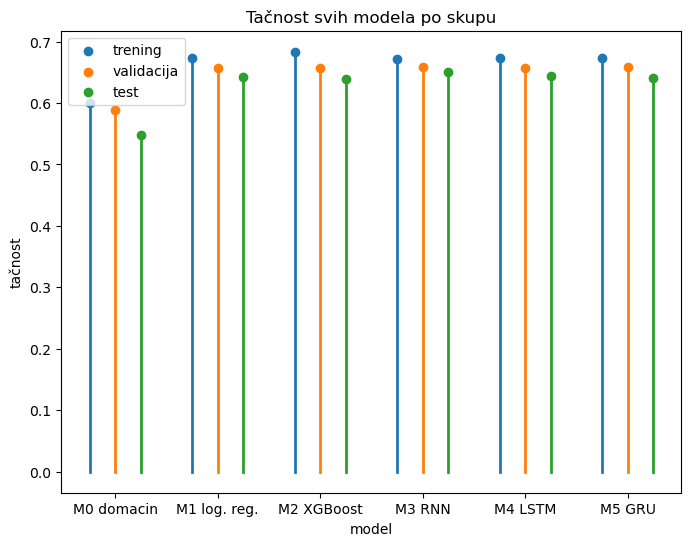

In [13]:
skupovi = ["trening", "validacija", "test"]
x = np.arange(len(plotting.MODEL_ORDER))
width = 0.25

plotting.new_figure("Tačnost svih modela po skupu", "model", "tačnost")
for i, skup in enumerate(skupovi):
    tacnosti = [
        df_rezultati[(df_rezultati["model"] == model) & (df_rezultati["skup"] == skup)]["tacnost"].iloc[0]
        for model in plotting.MODEL_ORDER
    ]
    offset_x = x + (i - 1) * width
    for xi, val in zip(offset_x, tacnosti):
        plt.plot([xi, xi], [0, val], linewidth=2, color=f"C{i}")
    plt.scatter(offset_x, tacnosti, label=skup, zorder=3, color=f"C{i}")
plt.xticks(x, plotting.MODEL_ORDER)
plt.legend()
plotting.save_figure("tacnost-po-skupu.png")
plt.show()


Vide se dva obrasca. Prvi je veliki skok sa M0 na M1, isti u sve tri podele — to je ceo doprinos modelovanja, i on je nedvosmislen. Drugi je da se M1 do M5 kreću praktično kao jedna grupa: gde jedan pada, padaju svi, i međusobni razmak je svuda manji od razmaka između podela.

Svi modeli su niži na testu nego na validaciji, a M0 najviše (58.9% → 54.8%). Pošto M0 ne uči ništa, taj pad ne može biti prekomerno prilagođavanje — dolazi iz same test sezone, u kojoj su domaćini pobeđivali ređe nego ranije. Deo pada ostalih modela je iz istog izvora, ne iz njihovih slabosti.

## Matrice konfuzije

Tačnost ne kaže kakve greške model pravi. Matrica konfuzije razdvaja dve vrste promašaja: propuštene pobede gosta i propuštene pobede domaćina.

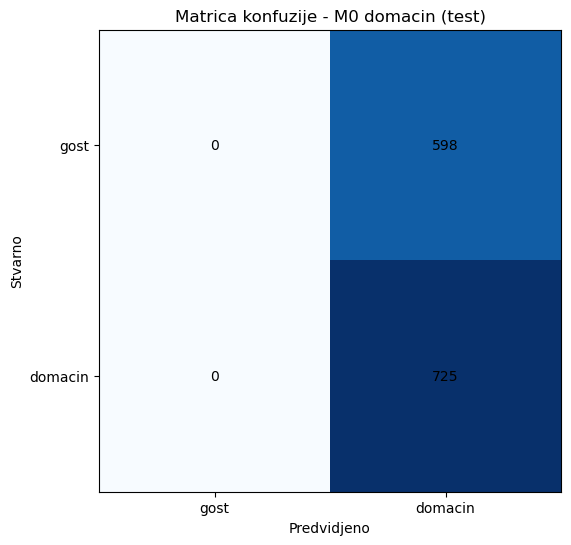

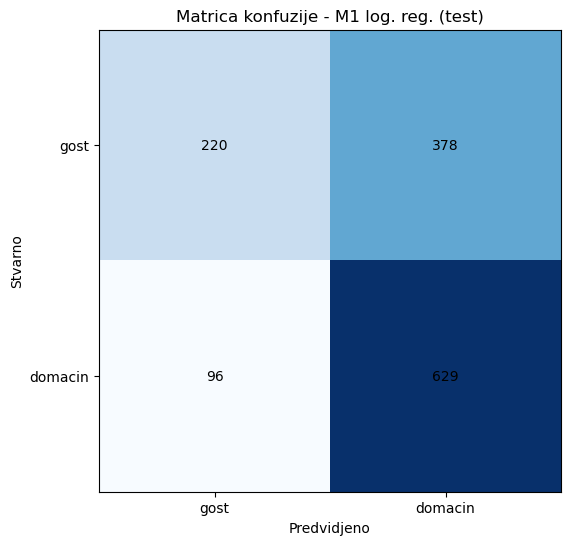

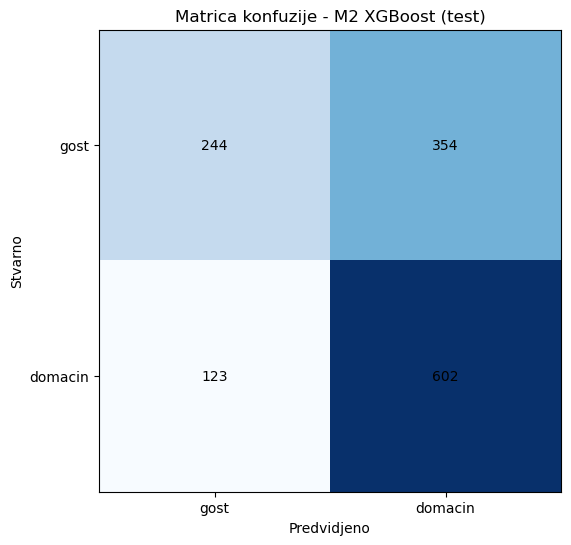

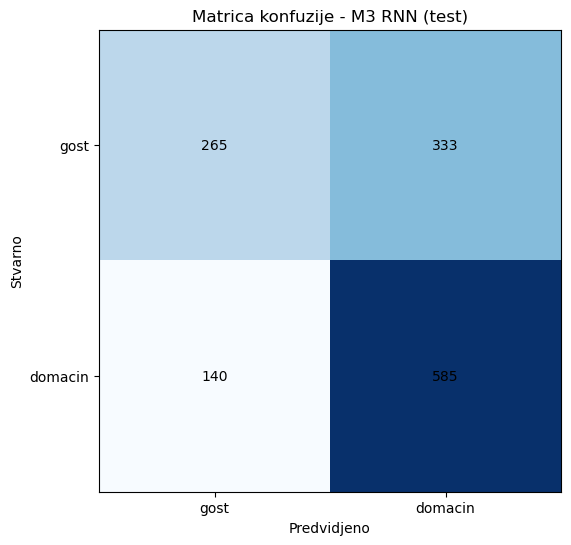

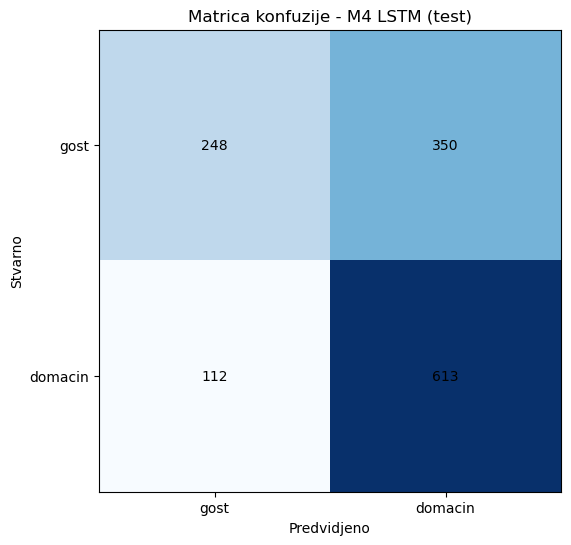

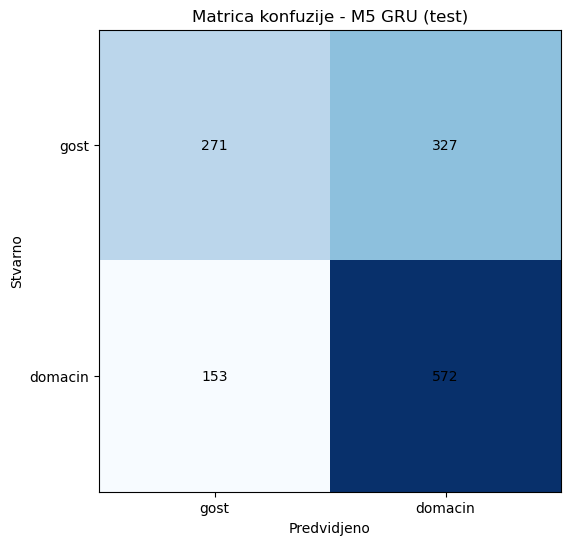

In [14]:
for name in plotting.MODEL_ORDER:
    y_proba, y_true = predictions[name]
    y_pred = (y_proba >= 0.5).astype(int)
    evaluate.plot_confusion_matrix(y_true, y_pred, f"Matrica konfuzije - {name} (test)")


Svi modeli su nagnuti ka domaćinu, i to jače nego što test sezona opravdava. Domaćin je stvarno pobedio u 54.8% mečeva, a modeli ga predviđaju u 68% (M5 GRU) do 76% (M1 log. reg.) slučajeva; M0 po definiciji u 100%. Zato su pobede domaćina prepoznate dobro (odziv 79–87%), a pobede gosta slabo (37–45%).

Nagib nije greška u kodu nego posledica podataka: modeli su učili na periodu u kome je domaćin pobeđivao u 59.9% mečeva, a ocenjuju se na sezoni sa 54.8%. Prag od 0.5 se pri toj promeni prelazi prečesto u korist domaćina. Zanimljivo je i da su mreže manje nagnute od logističke regresije — M5 GRU i M3 RNN najčešće „smeju" da izaberu gosta, i imaju najbolji odziv za tu klasu.

## ROC krive

Tačnost zavisi od izabranog praga, pa je osetljiva na nagib opisan gore. ROC kriva ga zaobilazi: meri koliko dobro model rangira mečeve po verovatnoći, kroz sve moguće pragove odjednom.

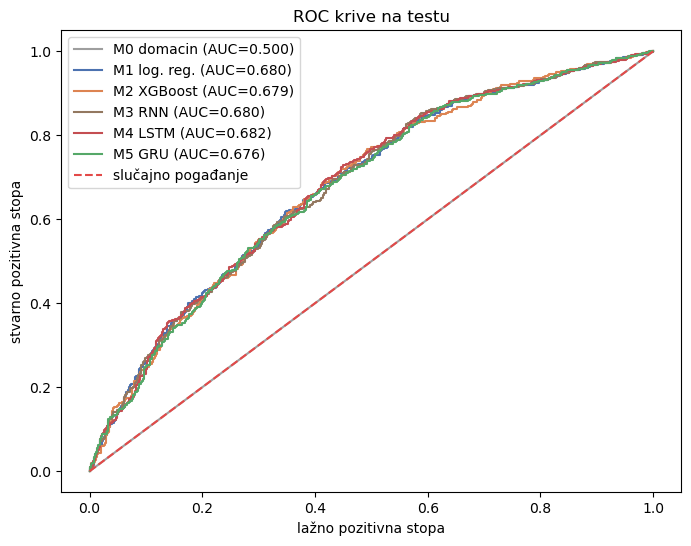

In [15]:
plotting.new_figure("ROC krive na testu", "lažno pozitivna stopa", "stvarno pozitivna stopa")
for name in plotting.MODEL_ORDER:
    y_proba, y_true = predictions[name]
    fpr, tpr, _ = sklearn_metrics.roc_curve(y_true, y_proba)
    auc = sklearn_metrics.roc_auc_score(y_true, y_proba)
    plt.plot(fpr, tpr, color=plotting.model_color(name), label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color=plotting.COLOR_WARNING, label="slučajno pogađanje")
plt.legend()
plotting.save_figure("roc-krive-test.png")
plt.show()


Krive M1–M5 se gotovo poklapaju: ROC-AUC ide od 0.676 (M5 GRU) do 0.682 (M4 LSTM), dakle raspon od 0.006. M0 leži tačno na dijagonali, sa AUC 0.500 — očekivano, jer daje istu verovatnoću svakom meču pa ne rangira ništa.

Ovo je nezavisna potvrda ranijeg nalaza. Rangiranje se meri drugom veličinom nego tačnost, ne zavisi od praga, i opet ne razdvaja pet netrivijalnih modela. Vredi primetiti i da se poredak po AUC-u razlikuje od poretka po tačnosti — još jedan znak da razlike nisu stabilne.

## Kalibracija

Model koji kaže „65%" trebalo bi da bude u pravu otprilike u 65% takvih mečeva. Ni tačnost ni ROC-AUC to ne proveravaju — prva gleda samo stranu praga, druga samo redosled. Za predviđanje sportskih ishoda kalibracija je bitna sama po sebi: verovatnoća se tumači kao procena, ne samo kao glas za jednu stranu.

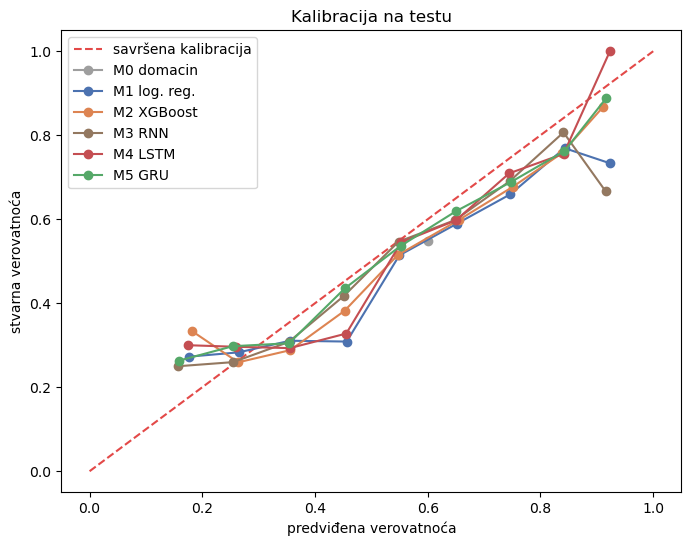

In [16]:
plotting.new_figure("Kalibracija na testu", "predviđena verovatnoća", "stvarna verovatnoća")
plt.plot([0, 1], [0, 1], linestyle="--", color=plotting.COLOR_WARNING, label="savršena kalibracija")
for name in plotting.MODEL_ORDER:
    y_proba, y_true = predictions[name]
    prob_true, prob_pred = calibration.calibration_curve(y_true, y_proba, n_bins=10)
    plt.plot(prob_pred, prob_true, marker="o", color=plotting.model_color(name), label=name)
plt.legend()
plotting.save_figure("kalibracija-test.png")
plt.show()


U srednjem delu opsega krive prate dijagonalu blizu, ali sve leže malo ispod nje: modeli dosledno daju nešto veću verovatnoću domaćinu nego što se ostvaruje. Prosečna predviđena verovatnoća je 0.58–0.62, a stvarni udeo 0.548 — isti pomak koji smo videli u matricama konfuzije, i istog porekla (trening period sa 59.9% pobeda domaćina).

Odstupanja su najveća na krajevima. Levo, kod niskih verovatnoća, modeli su previše sigurni u gosta: kad kažu 0.16–0.26, domaćin ipak pobeđuje u 25–33% slučajeva. Krajnje desno krive skaču neuredno (M4 LSTM na 1.00, M3 RNN na 0.67), ali u tu poslednju grupu pada svega 5 do 15 mečeva, pa je to šum a ne osobina modela.

## Robusnost: kovid sezone i „mehur"

Sezone 2019/20 i 2020/21 izdvojene su iz treninga, validacije i testa (`ANOMALY_SEASONS` u `config.py`), jer su ih pandemijske okolnosti učinile neuporedivim sa ostatkom skupa. Umesto da ih prosto odbacimo, koristimo ih ovde kao proveru robusnosti: model koji je naučio nešto opšte o košarci trebalo bi da ih podnese bez potpunog raspada.

Mečeve delimo na dva perioda po datumu prekida sezone (`SEASON_SUSPENSION_DATE`, 11.3.2020). Period posle prekida — koji zovemo „mehur" — širi je od doslovnog mehura u Orlandu (jul–oktobar 2020): obuhvata i taj nastavak i celu narednu sezonu 2020/21, odigranu bez publike ili sa ograničenim brojem gledalaca. Zajedničko im je upravo ono što nas zanima — izostanak publike koja stvara prednost domaćeg terena.

Napomena o čitanju brojeva: modeli ove mečeve nikada nisu videli u treningu, ali ih ni ne treba tumačiti kao „drugi test skup". Sekvence i pokretne statistike za te mečeve računate su isto kao svuda, pa je poređenje dva perioda međusobno pošteno.

Vredi razjasniti i šta „izdvojene sezone" ovde znače. One su izuzete kao mečevi koje predviđamo, ali ne i kao prošlost iz koje se atributi računaju: sekvenca test meča iz 2021/22 sadrži prethodne mečeve tih timova, među njima i one iz 2020/21, a Elo rejting teče kroz ceo period neprekidno. Tako i treba da bude — u trenutku predviđanja model sme da koristi sve što se dotad odigralo. Izbačeno je samo ono što bi kvarilo merenje: pandemijski mečevi kao primeri za treniranje i za ocenjivanje.

In [17]:
anomaly = splits["anomaly"]
indices = splits["indices"]

df_games = data.clean_games(data.load_games())
anomaly_dates = df_games.loc[indices[anomaly], "GAME_DATE_EST"]
is_bubble = (anomaly_dates >= SEASON_SUSPENSION_DATE).to_numpy()

int((~is_bubble).sum()), int(is_bubble.sum())


(967, 1347)

In [18]:
home_anomaly, away_anomaly, context_anomaly = home_sequences[anomaly], away_sequences[anomaly], context[anomaly]
y_anomaly, X_anomaly = y[anomaly], X.iloc[anomaly]

robust_rows = []
for name in plotting.MODEL_ORDER:
    for opis, mask in [("pre prekida", ~is_bubble), ("mehur", is_bubble)]:
        if name == "M0 domacin":
            y_proba = np.full(int(mask.sum()), base_rate)
        elif name in ("M1 log. reg.", "M2 XGBoost"):
            model = model_log_reg if name == "M1 log. reg." else model_xgb
            y_proba = model.predict_proba(X_anomaly[mask])[:, 1]
        else:
            # isti reprezentativni prolaz (seed RANDOM_STATE) kao u ostatku sveske
            params = HYPERPARAMS[name]
            model = models.MatchPredictor(
                n_features=n_features, n_context=n_context,
                cell=params["cell"], hidden_size=params["hidden_size"], dropout=params["dropout"],
            )
            model.load_state_dict(
                torch.load(MODELS_PATH / f"{params['cell']}_seed{RANDOM_STATE}.pt", weights_only=True)
            )
            loader = DataLoader(
                sequences.MatchSequenceDataset(
                    home_anomaly[mask], away_anomaly[mask], context_anomaly[mask], y_anomaly[mask]
                ),
                batch_size=64, shuffle=False,
            )
            y_proba, _ = train.predict_proba(model, loader)

        metrike = evaluate.compute_metrics(y_anomaly[mask], y_proba)
        robust_rows.append({"model": name, "period": opis, "n": int(mask.sum()), **metrike})

df_robust = pd.DataFrame(robust_rows)
df_robust.round(4)


,model,period,n,tacnost,roc_auc,log_loss,brier
0,M0 domacin,pre prekida,967,0.5512,0.5000,0.6927,0.2497
1,M0 domacin,mehur,1347,0.5434,0.5000,0.6958,0.2513
2,M1 log. reg.,pre prekida,967,0.6546,0.7126,0.6233,0.2170
3,M1 log. reg.,mehur,1347,0.5954,0.6563,0.6676,0.2369
4,M2 XGBoost,pre prekida,967,0.6618,0.7087,0.6234,0.2170
5,M2 XGBoost,mehur,1347,0.6088,0.6596,0.6620,0.2345
6,M3 RNN,pre prekida,967,0.6598,0.7117,0.6184,0.2148
7,M3 RNN,mehur,1347,0.6095,0.6519,0.6609,0.2339
8,M4 LSTM,pre prekida,967,0.6577,0.7125,0.6191,0.2153
9,M4 LSTM,mehur,1347,0.5991,0.6534,0.6617,0.2345


U tabeli iznad M0 pada osetno manje od ostalih modela. Pošto je M0-ova tačnost doslovno stopa pobeda domaćina u datom periodu, ta razlika je direktna procena promene prednosti domaćeg terena — pa je proveravamo dvouzoračkim testom proporcija pre nego što bilo šta zaključimo iz nje.

In [19]:
m0_pre = df_robust[(df_robust["model"] == "M0 domacin") & (df_robust["period"] == "pre prekida")].iloc[0]
m0_mehur = df_robust[(df_robust["model"] == "M0 domacin") & (df_robust["period"] == "mehur")].iloc[0]

p1, n1 = m0_pre["tacnost"], int(m0_pre["n"])
p2, n2 = m0_mehur["tacnost"], int(m0_mehur["n"])

se = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
z = (p1 - p2) / se
p_vrednost_m0 = 2 * (1 - stats.norm.cdf(abs(z)))

p1, p2, z, p_vrednost_m0


(0.5511892450879007,
 0.5434298440979956,
 0.36990688111249287,
 0.7114518741641538)

Svih pet netrivijalnih modela pada u „mehuru", i to dosledno: tačnost se spušta za 5.0 do 5.9 procentnih poena (najviše M1 log. reg., najmanje M3 RNN). Pad je red veličine veći od rasipanja po seedovima (0.4 p.p.), pa nije stvar izbora prolaza.

**M0 pri tome pada mnogo manje** — sa 55.1% na 54.3%, svega 0.8 procentnih poena — a test iznad pokazuje da ta razlika nije statistički značajna (z = 0.37, p = 0.71).

To obara očekivanje zapisano uz `SEASON_SUSPENSION_DATE` u `config.py`, gde stoji da prednost domaćeg terena u tom periodu „praktično nestaje". M0 je doslovna mera te prednosti, i on je ne vidi kako nestaje. Preciznije rečeno: podaci isključuju nestanak, ali ne mogu da potvrde ni da je uopšte oslabila — razlika od 0.8 p.p. se na ovom uzorku ne razlikuje od šuma.

Ostaje pitanje odakle onda pad kod M1–M5. Ono što ti modeli koriste a M0 ne jesu pokretni proseci, Elo i stanje na tabeli — veličine koje pretpostavljaju uobičajen ritam sezone, a on je u tom periodu bio poremećen (skraćen raspored, duge pauze, izmenjeni sastavi). To je uverljivo objašnjenje, ali ga ovde ne testiramo direktno, pa ostaje hipoteza: nismo isključile ni jednostavniju mogućnost da su ekipe u sezoni 2020/21. bile drugačije po jačini nego pre prekida.

## Zaključak

**Lestvica modela se zaustavlja posle prvog koraka.** M0 (uvek domaćin) meri samu prednost domaćeg terena, i ona opada kroz sve tri podele: 59.9% na treningu, 58.9% na validaciji, 54.8% na testu. Svih pet netrivijalnih modela je ubedljivo iznad te granice — McNemarov test daje p < 0.001 u svakom od pet parova — i svi dostižu 63.9–65.0% tačnosti na testu (ROC-AUC 0.679–0.681, za mreže prosek po pet seedova). Ali među sobom, M1–M5 nemaju nijedan statistički značajan par: najbliži granici je M4 LSTM naspram M5 GRU sa p = 0.057, a i to bez korekcije za deset istovremenih poređenja.

**Glavni nalaz projekta je negativan, i to je u redu.** Arhitektonska složenost — obična RNN, pa LSTM, pa GRU — ne kupuje ništa merljivo preko logističke regresije nad agregatnim atributima. Nalaz stoji na tri nezavisna oslonca: nijedan par među M1–M5 nije statistički značajan, modeli daju isti odgovor na preko 90% mečeva, a poredak se menja čim se promeni metrika ili seed (po prosečnoj tačnosti vodi M3, po ROC-AUC M4). Interpretacija koeficijenata u svesci 03 pokazuje i zašto: Elo rejting nosi najveći deo signala. Pravi dobitak u ovom projektu došao je iz *atributa* (Elo, stanje na tabeli, međusobni dueli), ne iz izbora modela. To se poklapa sa time kako se snaga NBA tima ponaša — unutar sezone se menja sporo, pa je pokretni prosek blizu dovoljne statistike, a redosled prethodnih mečeva nosi malo dodatne informacije.

**Provera robusnosti dala je nalaz suprotan polaznoj pretpostavci.** U periodu posle prekida sezone 2019/20 svih pet netrivijalnih modela gubi 5.0–5.9 procentnih poena tačnosti. Očekivano objašnjenje bilo bi da prednost domaćeg terena bez publike nestaje — to je i zapisano u `config.py` kao razlog za izdvajanje tih sezona. Ali M0, koji je doslovna mera te prednosti, pada svega 0.8 procentnih poena, i ta razlika nije statistički značajna (p = 0.71). Prednost domaćeg terena, dakle, ne nestaje; da li uopšte slabi, ovi podaci ne mogu pouzdano da kažu. Verovatniji uzrok pada kod M1–M5 je poremećen ritam sezone, koji kvari pokretne proseke i Elo a M0 ne dotiče — ali to ostaje hipoteza, ne utvrđen uzrok.

**Ograničenja.** Test je jedna sezona (1323 meča), pa su intervali poverenja široki oko ±2.6 procentna poena i ne bi razdvojili ni razlike od dva poena. Modeli su nagnuti ka domaćinu jače nego što test sezona opravdava, i verovatnoće bi pre ozbiljne upotrebe trebalo dodatno kalibrisati. Zaključak „mreže ne pomažu" važi za ovaj skup, ovaj skup atributa i ovaj horizont predviđanja — ne uopšteno.

Pošteno izveden negativan rezultat vredi više od nategnutog pozitivnog. Nijedan model ovde nije „pobednik", a to je samo po sebi nalaz: za ovaj problem, agregatni atributi nose praktično sav signal koji se da izvući.